In [1]:
import numpy as np
import matplotlib.pyplot as plt
import optuna
import pandas as pd

/home/james/Repo/PhD Repo/time_series_clustering/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import itertools
import tqdm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.base import BaseEstimator
from sklearn.metrics import silhouette_score, rand_score, adjusted_rand_score
from sklearn.cluster import KMeans

In [4]:
from time_series.time_series_models import KernelRidgeRegression, RascuttiModel
from time_series.data_generators import LorenzGenerator
from time_series.kernels import GaussianKernel
from time_series.evaluators import MeanSquaredError

2025-11-24 11:55:21.971 | INFO     | time_series.config:<module>:13 - PROJ_ROOT path is: /home/james/Repo/PhD Repo/time_series_clustering


In [5]:
from collections import defaultdict

In [6]:
class DataHolder:
    def __init__(self, **kwargs):
        self.update(**kwargs)
    
    def update(self, **kwargs):
        self.__dict__.update(kwargs)

In [7]:
class GridSearch:
    def __init__(self, estimator, param_grid, scoring=None, nfolds=5):
        self.estimator = estimator
        self.param_grid = param_grid
        self.scoring = scoring if scoring else mean_squared_error
        self.nfolds = nfolds
    
    def fit(self, X, y=None):
        param_names = list(self.param_grid.keys())
        param_values = list(itertools.product(*self.param_grid.values()))

        result = []

        best_score = np.inf
        best_params = []
        
        for p in param_values:
            mapping = {param_names[i]:p[i] for i in range(len(param_names))}
            model = self.estimator(**mapping)

            kf = KFold(n_splits=self.nfolds, random_state=None, shuffle=False)
            scores = []
            
            for i, (train_index, test_index) in enumerate(kf.split(X)):
                X_train = X[train_index]
                X_test = X[test_index]

                y_train = y[train_index]
                y_test = y[test_index] 

                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)

                score = self.scoring(y_test, y_pred)
                scores.append(score)
            
            cv_score = np.mean(scores)
            result.append(
                (mapping, cv_score)
            )

            if cv_score < best_score:
                best_score = cv_score
                best_params = p
        
        self.best_score = best_score
        self.best_params = {param_names[i]:best_params[i] for i in range(len(param_names))}

        self.cv_results = result


In [8]:
class OptunaHyperparameterTuning:
    def __init__(self, estimator, param_grid, scoring=None, nfolds=5, n_trials=30):
        self.estimator = estimator
        self.param_grid = param_grid
        self.scoring = scoring if scoring else mean_squared_error
        self.nfolds = nfolds
        self.n_trials = n_trials
    
    def fit(self, X, y=None):
        def objective(trial):
            parameters = dict()

            for p_name, p_params in self.param_grid.items():
                if p_params["type"] == "float":
                    step = p_params["step"] if "step" in p_params else None
                    parameters[p_name] = trial.suggest_float(p_name, p_params["min"], p_params["max"], step=step)

                elif p_params["type"] == "fixed":
                    parameters[p_name] = p_params["value"]
            
            model = self.estimator(**parameters)

            kf = KFold(n_splits=self.nfolds, random_state=None, shuffle=False)
            scores = []
            
            for i, (train_index, test_index) in enumerate(kf.split(X)):
                X_train = X[train_index]
                X_test = X[test_index]

                y_train = y[train_index]
                y_test = y[test_index] 

                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)

                score = self.scoring(y_test, y_pred)
                scores.append(score)
            
            cv_score = np.mean(scores)
            return cv_score


        study = optuna.create_study()
        study.optimize(
            objective,
            n_trials=self.n_trials,
        )

        self.best_params = study.best_params

In [9]:
class KRRWrapper(BaseEstimator):
    def __init__(self, bandwidth, reg):
        self.model = KernelRidgeRegression(
            kernels=[GaussianKernel(bandwidth=bandwidth)],
            reg = reg
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

In [10]:
x = np.linspace(-4, 4, 500)

y1 = np.exp(-x**2)
y2 = np.exp(-10*x**2)

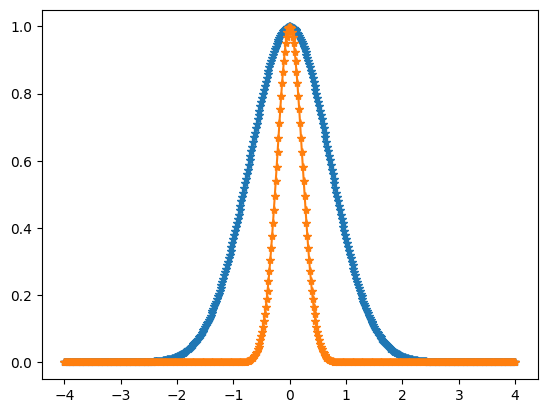

In [11]:
plt.plot(x, y1, "-*")
plt.plot(x, y2, "-*")

In [12]:
# paramsearch = OptunaHyperparameterTuning(
#     KRRWrapper,
#     param_grid={
#         "bandwidth": dict(type="float", min=1e-9, max=4),
#         "reg": dict(type="float", min=1e-12, max=1e-2)
#     },
#     scoring=mean_squared_error,
#     n_trials=100
# )

paramsearch = GridSearch(
    KRRWrapper,
    param_grid={
        "bandwidth": np.linspace(0.1, 4, 15),
        "reg": [10**(-i) for i in range(2, 10)]
    },
    scoring=mean_squared_error,
)

In [13]:
paramsearch.fit(x, y1)
bandwidth = paramsearch.best_params["bandwidth"]
reg = paramsearch.best_params["reg"]

model1 = KernelRidgeRegression(
    kernels=[
        GaussianKernel(bandwidth=bandwidth)
    ],
    reg = reg,
    lag=1
)

model1.fit(x, y1)
y1_pred = model1.predict(x)

print(mean_squared_error(y1, y1_pred), bandwidth, reg)

4.1524451805024775e-12 0.9357142857142857 1e-09


In [14]:
paramsearch.fit(x, y2)
bandwidth = paramsearch.best_params["bandwidth"]
reg = paramsearch.best_params["reg"]

model2 = KernelRidgeRegression(
    kernels=[
        GaussianKernel(bandwidth=bandwidth)
    ],
    reg = reg,
    lag=1
)

model2.fit(x, y2)
y2_pred = model2.predict(x)

mean_squared_error(y2, y2_pred)

1.4332135661377811e-08

In [15]:
print([mean_squared_error(y1, y1_pred), mean_squared_error(y1, y2_pred)])
print([mean_squared_error(y2, y1_pred), mean_squared_error(y2, y2_pred)])

[4.1524451805024775e-12, 0.07245682675462839]
[0.0724571311994226, 1.4332135661377811e-08]


In [16]:
np.array([
    [(model1.alpha.T@y1_pred)[0][0], (model1.alpha.T@y2_pred)[0][0]],
    [(model2.alpha.T@y1_pred)[0][0], (model2.alpha.T@y2_pred)[0][0]]
])

array([[  1.31206687, 107.81757905],
       [  0.52429946,  39.07718973]])

In [17]:
(model1.alpha.T@model2.alpha)/np.sqrt((model1.alpha.T@model1.alpha)*(model2.alpha.T@model2.alpha))

array([[0.0001068]])

# Sweep without tuning

In [42]:
def inner_product(m1, m2):
    K = GaussianKernel(bandwidth=1)
    return m1.alpha.T@K(m1.x_train/m1.kernels[0].bandwidth, m2.x_train/m2.kernels[0].bandwidth)@m2.alpha

def inner_product_b1(m1, m2):
    K = GaussianKernel(bandwidth=1)
    return m1.alpha.T@K(m1.x_train, m2.x_train)@m2.alpha

## Sweep bandwidth

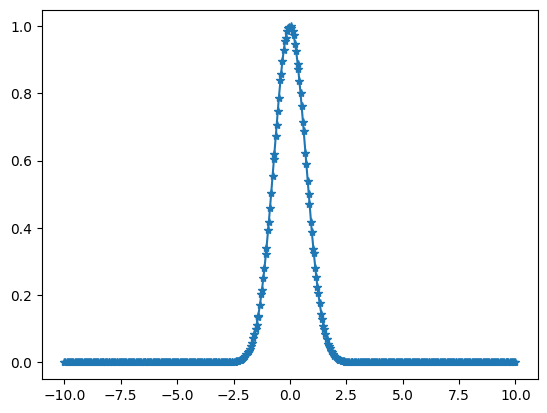

In [43]:
x = np.linspace(-10, 10, 400)
x += np.random.normal(0, 0.01, len(x))

y1 = np.exp(-x**2)

plt.plot(x, y1, "-*")

In [52]:
bandwidth = 1
reg = 1e-4

alphas = np.linspace(0.01, 3, 50)

In [53]:
model1 = KernelRidgeRegression(
    kernels=[
        GaussianKernel(bandwidth=bandwidth)
    ],
    reg = reg,
    lag=1
)

model1.fit(x, y1)
y1_pred = model1.predict(x)

mean_squared_error(y1, y1_pred)

1.0932301596089094e-05

In [54]:
results = defaultdict(list)

ip1 = inner_product(model1, model1)

for alpha in tqdm.tqdm(alphas):
    temp_results = defaultdict(list)

    for i in range(10):
        y = np.exp(-(x/alpha)**2) + np.random.normal(0, 0.01, len(x))

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=bandwidth)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)
        ip21 = inner_product(model, model1)

        temp_results["mse"].append(mean_squared_error(y, y_pred))
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

        temp_results["dist1"].append((
            model1.alpha.T@model1.predict(x) + \
            model.alpha.T@model.predict(x) - \
            model1.alpha.T@model.predict(x*model.kernels[0].bandwidth/model1.kernels[0].bandwidth) - \
            model.alpha.T@model1.predict(x*model1.kernels[0].bandwidth/model.kernels[0].bandwidth)                  
        )[0][0])

        temp_results["dist2"].append((ip1 + ip2 - ip12 - ip21)[0][0])
        
        temp_results["$\\|f1\\|^2$"].append(ip1)
        temp_results["$\\|f2\\|^2$"].append(ip2)
        temp_results["$\\langle f1, f2 \\rangle$"].append(ip12)

    for k, v in temp_results.items():
        results[k].append(np.mean(v))

100%|██████████| 50/50 [00:11<00:00,  4.52it/s]


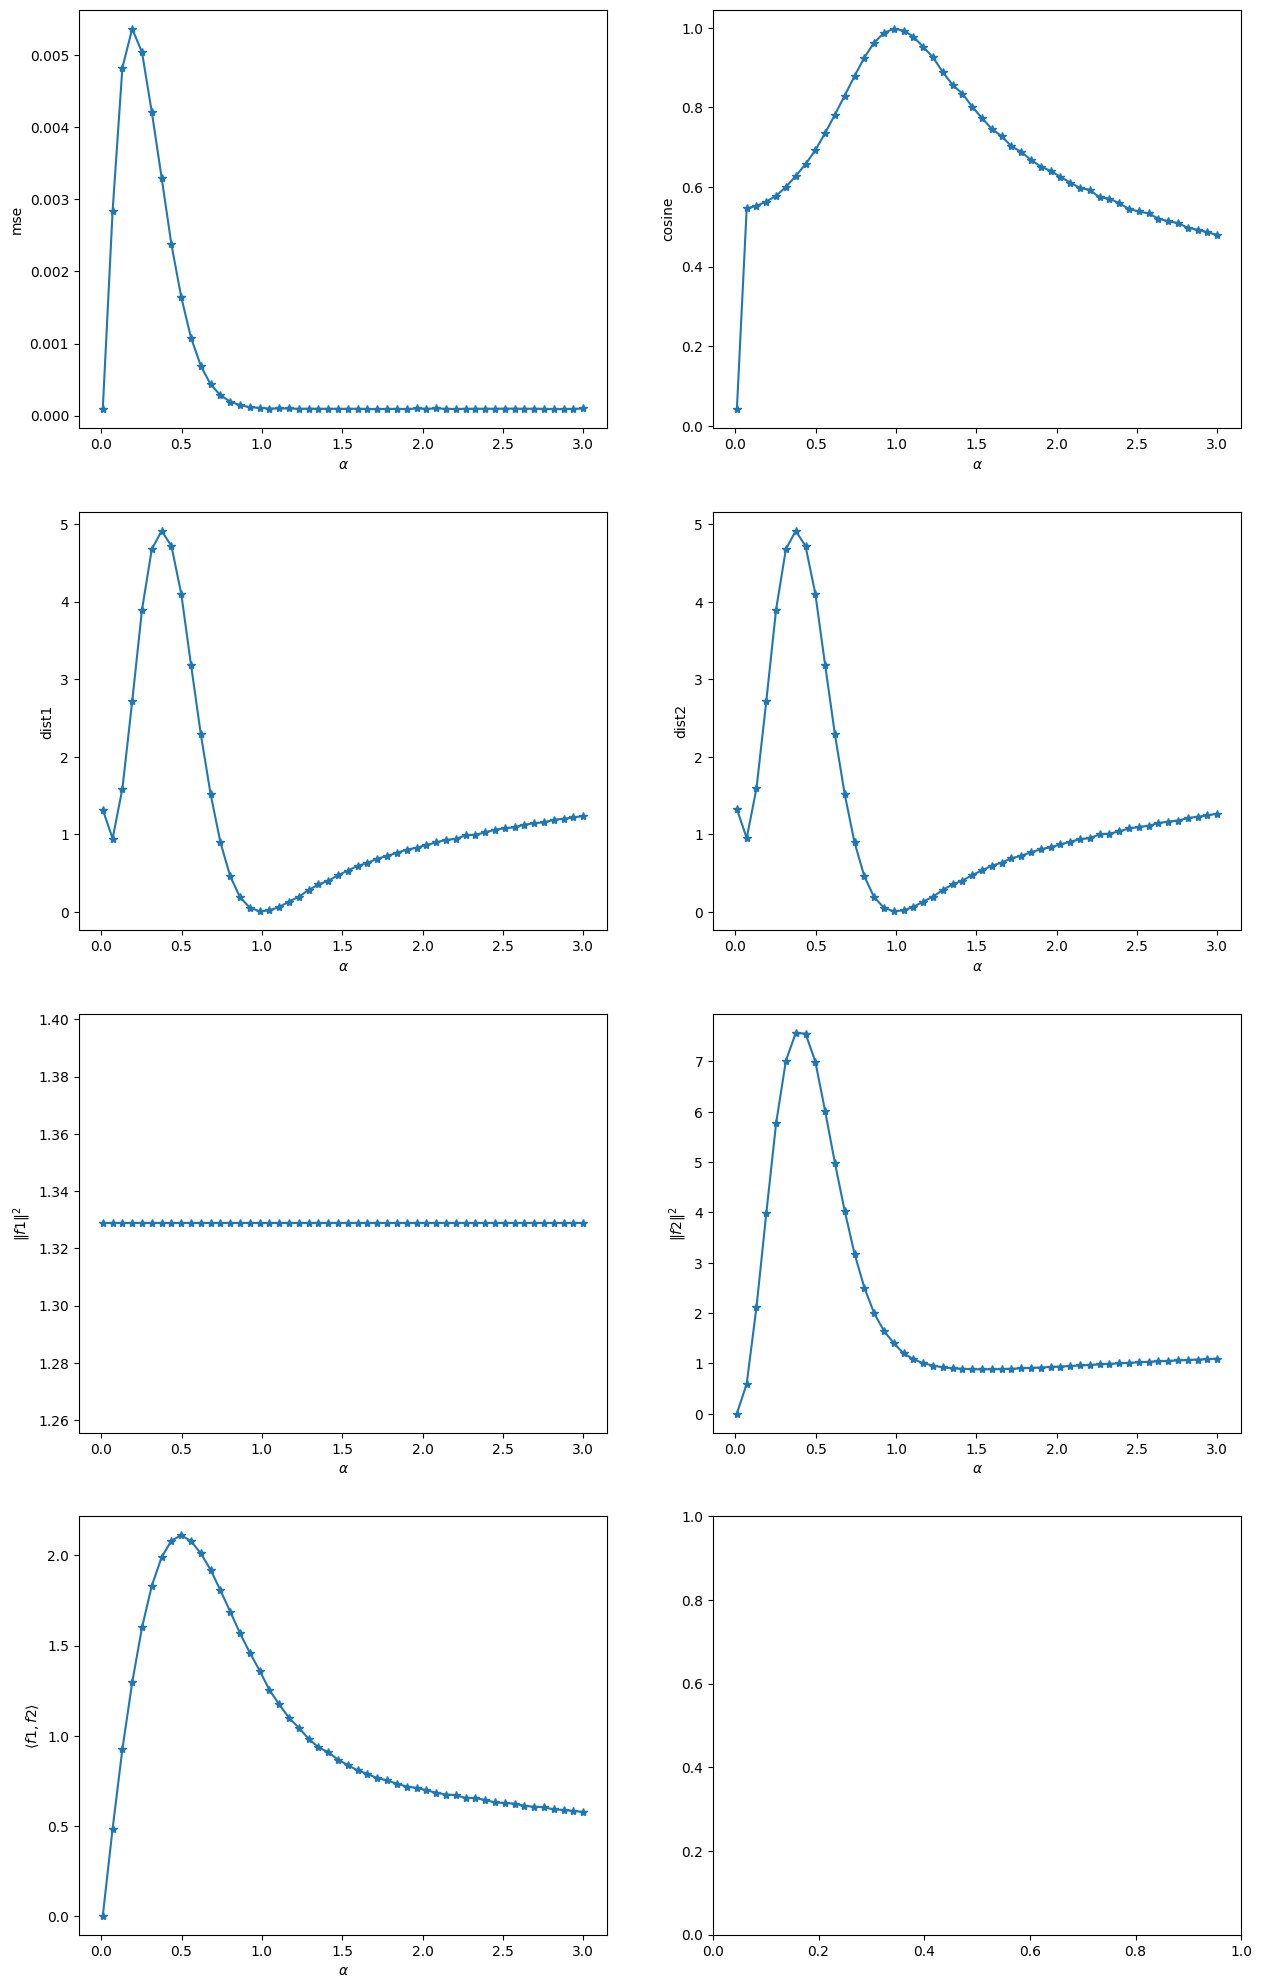

In [55]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 25))

for k, ax_ in zip(results.keys(), ax.flat):
    ax_.plot(alphas[:len(results[k])], results[k], "-*")
    ax_.set_ylabel(k)
    ax_.set_xlabel("$\\alpha$")

## Sweep shift

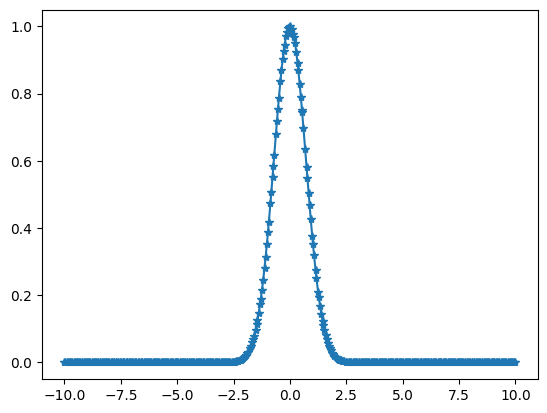

In [27]:
x = np.linspace(-10, 10, 400)
x += np.random.normal(0, 0.01, len(x))

y1 = np.exp(-x**2)

plt.plot(x, y1, "-*")

In [28]:
bandwidth = 1
reg = 1e-7

alphas = np.linspace(-6, 6, 100)

In [29]:
model1 = KernelRidgeRegression(
    kernels=[
        GaussianKernel(bandwidth=bandwidth)
    ],
    reg = reg,
    lag=1
)

model1.fit(x, y1)
y1_pred = model1.predict(x)

mean_squared_error(y1, y1_pred)

7.602843627423315e-09

In [30]:
results = defaultdict(list)

ip1 = inner_product(model1, model1)

for alpha in tqdm.tqdm(alphas):
    temp_results = defaultdict(list)

    for i in range(10):
        y = np.exp(-(x- alpha)**2) + np.random.normal(0, 0.01, len(x))

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=bandwidth)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)
        ip21 = inner_product(model, model1)

        temp_results["mse"].append(mean_squared_error(y, y_pred))
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

        temp_results["dist1"].append((
            model1.alpha.T@model1.predict(x) + \
            model.alpha.T@model.predict(x) - \
            model1.alpha.T@model.predict(x*model.kernels[0].bandwidth/model1.kernels[0].bandwidth) - \
            model.alpha.T@model1.predict(x*model1.kernels[0].bandwidth/model.kernels[0].bandwidth)                  
        )[0][0])

        temp_results["dist2"].append((ip1 + ip2 - ip12 - ip21)[0][0])
        
        temp_results["$\\|f1\\|^2$"].append(ip1)
        temp_results["$\\|f2\\|^2$"].append(ip2)
        temp_results["$\\langle f1, f2 \\rangle$"].append(ip12)

    for k, v in temp_results.items():
        results[k].append(np.mean(v))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:30<00:00,  3.33it/s]


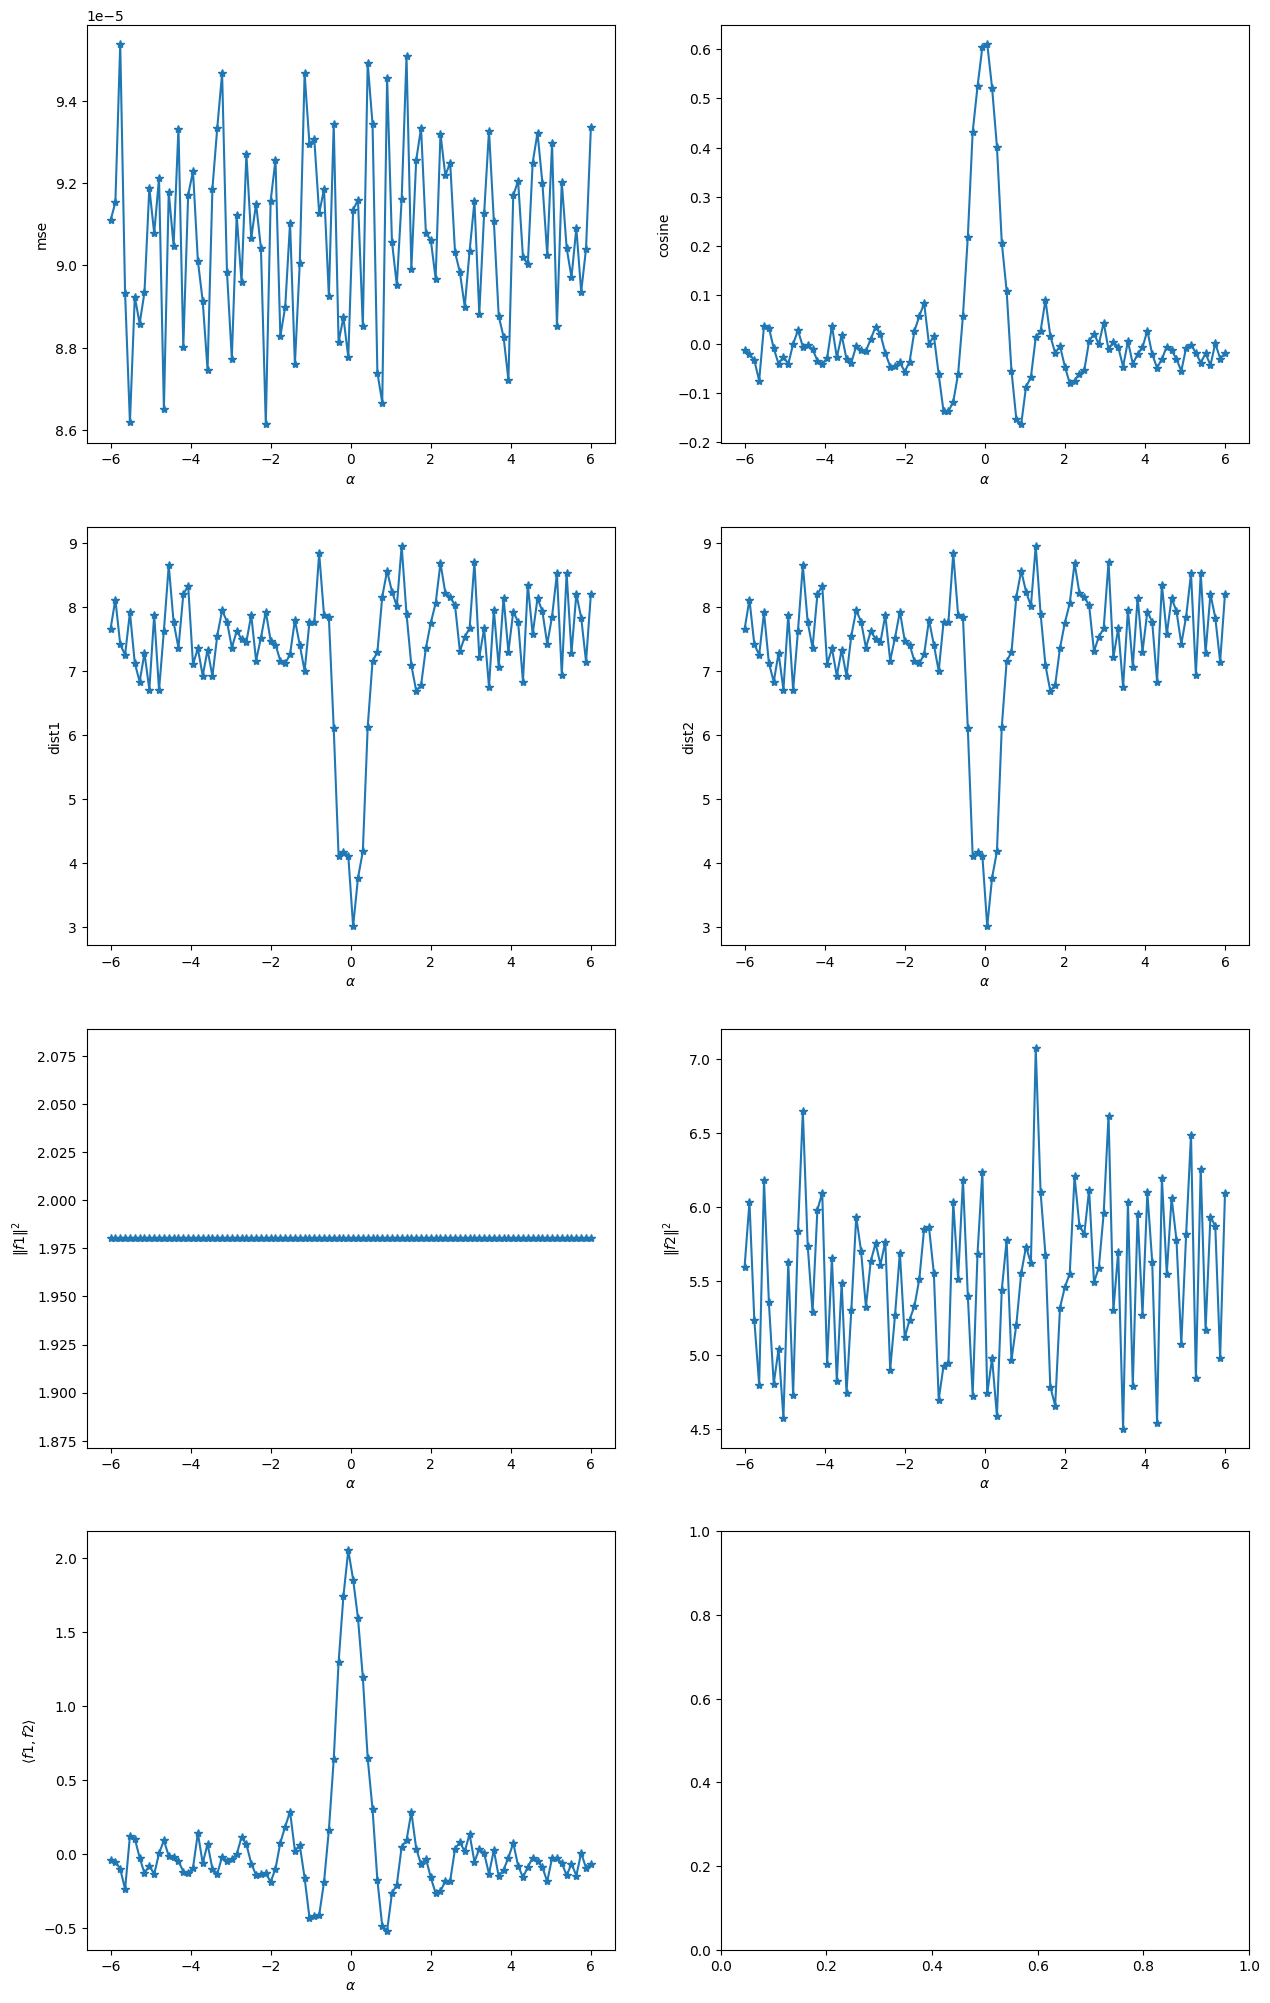

In [31]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 25))

for k, ax_ in zip(results.keys(), ax.flat):
    ax_.plot(alphas[:len(results[k])], results[k], "-*")
    ax_.set_ylabel(k)
    ax_.set_xlabel("$\\alpha$")

# Sweep with param tuning

## Sweep bandwidth

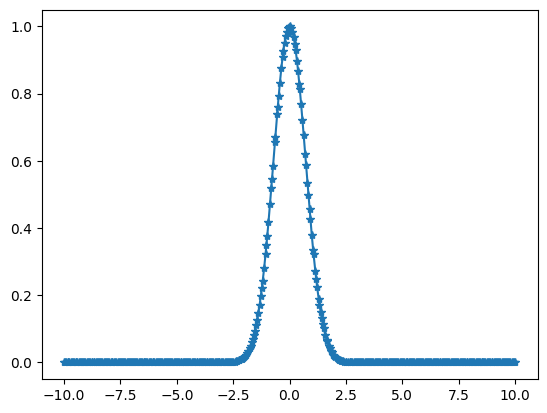

In [56]:
x = np.linspace(-10, 10, 400)
x += np.random.normal(0, 0.01, len(x))

y1 = np.exp(-x**2)

plt.plot(x, y1, "-*")

In [57]:
alphas = np.linspace(0.01, 3, 50)

In [58]:
paramsearch = OptunaHyperparameterTuning(
    KRRWrapper,
    param_grid={
        "bandwidth": dict(type="float", min=1e-7, max=4),
        "reg": dict(type="float", min=1e-12, max=1e-2)
    },
    scoring=mean_squared_error,
    n_trials=100
)

In [59]:
paramsearch.fit(x, y1)
bandwidth = paramsearch.best_params["bandwidth"]
reg = paramsearch.best_params["reg"]

model1 = KernelRidgeRegression(
    kernels=[
        GaussianKernel(bandwidth=bandwidth)
    ],
    reg = reg,
    lag=1
)

model1.fit(x, y1)
y1_pred = model1.predict(x)

mean_squared_error(y1, y1_pred)

5.837827462245392e-05

In [60]:
results = defaultdict(list)

ip1 = inner_product(model1, model1)
ip1_b1 = inner_product_b1(model1, model1)

for alpha in tqdm.tqdm(alphas):
    temp_results = defaultdict(list)

    for i in range(10):
        y = np.exp(-(x/alpha)**2) + np.random.normal(0, 0.01, len(x))

        paramsearch.fit(x, y)
        bandwidth = paramsearch.best_params["bandwidth"]
        reg = paramsearch.best_params["reg"]

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=bandwidth)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)
        ip21 = inner_product(model, model1)

        ip2_b1 = inner_product_b1(model, model)
        ip12_b1 = inner_product_b1(model1, model)
        ip21_b1 = inner_product_b1(model, model1)

        temp_results["mse"].append(mean_squared_error(y, y_pred))
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))
        temp_results["cosine_b1"].append(ip12_b1/np.sqrt(ip1_b1*ip2_b1))

        temp_results["dist1"].append((
            model1.alpha.T@model1.predict(x) + \
            model.alpha.T@model.predict(x) - \
            model1.alpha.T@model.predict(x*model.kernels[0].bandwidth/model1.kernels[0].bandwidth) - \
            model.alpha.T@model1.predict(x*model1.kernels[0].bandwidth/model.kernels[0].bandwidth)                  
        )[0][0])

        temp_results["dist2"].append((ip1 + ip2 - ip12 - ip21)[0][0])        
        temp_results["dist2_b1"].append((ip1_b1 + ip2_b1 - ip12_b1 - ip21_b1)[0][0])
        
        temp_results["$\\|f1\\|^2$"].append(ip1)
        temp_results["$\\|f2\\|^2$"].append(ip2)
        temp_results["$\\langle f1, f2 \\rangle$"].append(ip12)

        temp_results["$\\|f1_b1\\|^2$"].append(ip1_b1)
        temp_results["$\\|f2_b1\\|^2$"].append(ip2_b1)
        temp_results["$\\langle f1_b1, f2_b1 \\rangle$"].append(ip12_b1)

    for k, v in temp_results.items():
        results[k].append(np.mean(v))

100%|██████████| 50/50 [14:03<00:00, 16.87s/it]


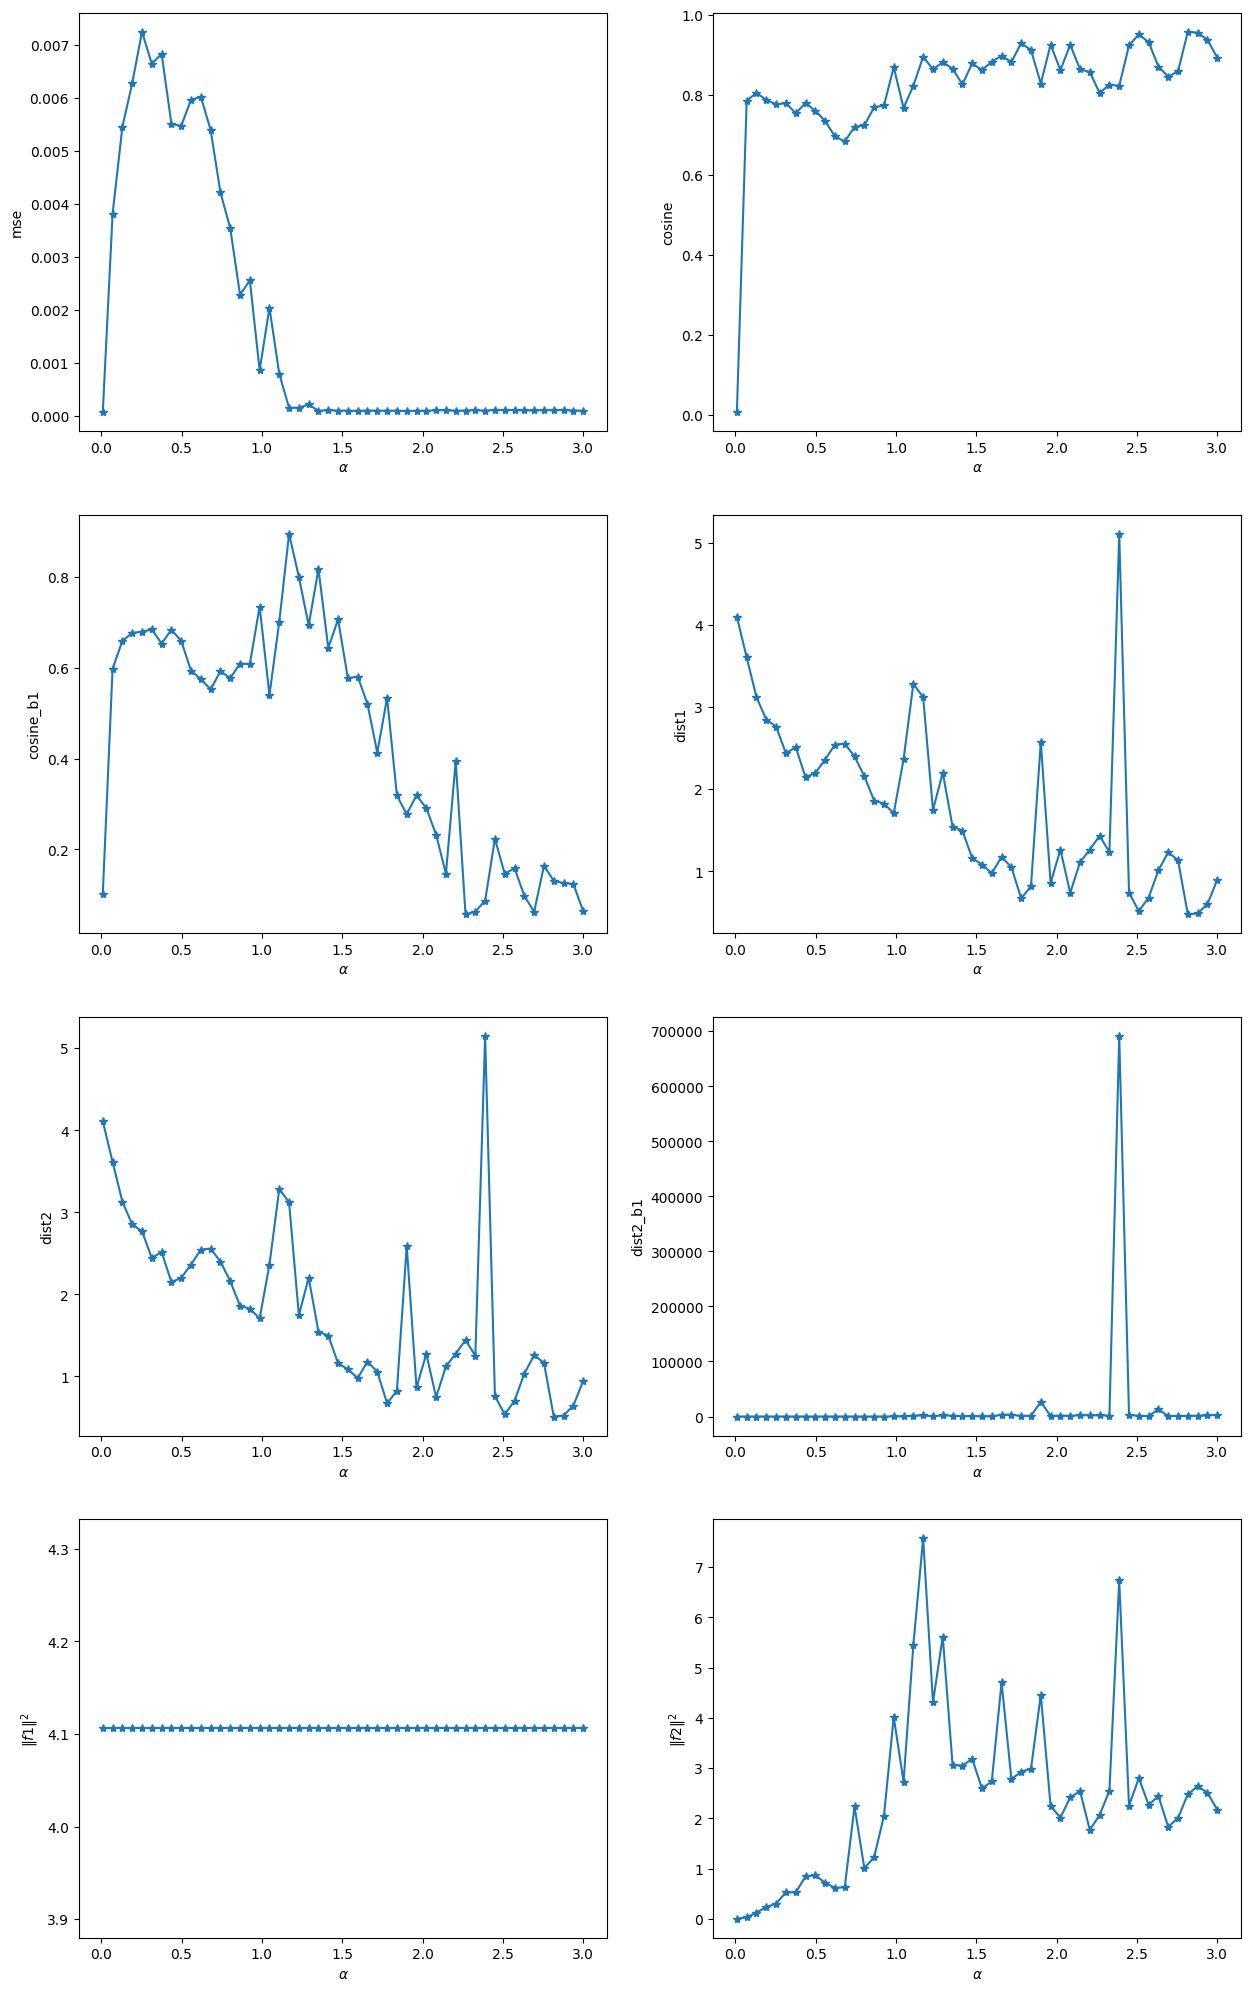

In [61]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 25))

for k, ax_ in zip(results.keys(), ax.flat):
    ax_.plot(alphas[:len(results[k])], results[k], "-*")
    ax_.set_ylabel(k)
    ax_.set_xlabel("$\\alpha$")

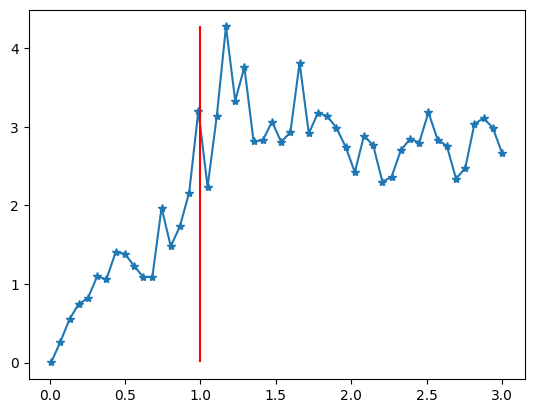

In [65]:
plt.plot(alphas, results["$\\langle f1, f2 \\rangle$"], "-*")
plt.vlines(1, min(results["$\\langle f1, f2 \\rangle$"]), max(results["$\\langle f1, f2 \\rangle$"]), color="red")

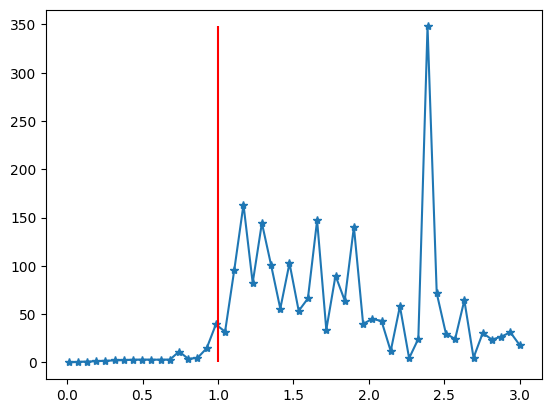

In [66]:
plt.plot(alphas, results["$\\langle f1_b1, f2_b1 \\rangle$"], "-*")
plt.vlines(1, min(results["$\\langle f1_b1, f2_b1 \\rangle$"]), max(results["$\\langle f1_b1, f2_b1 \\rangle$"]), color="red")

## Sweep shift

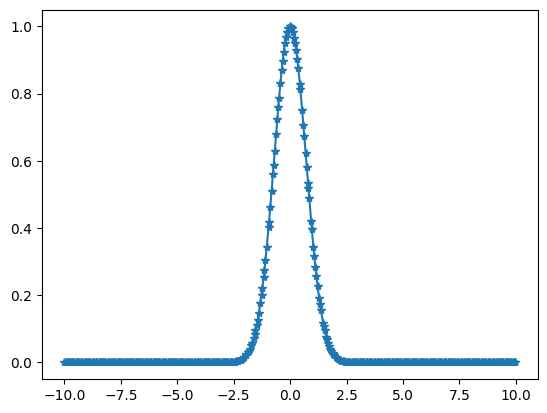

In [67]:
x = np.linspace(-10, 10, 400)
x += np.random.normal(0, 0.01, len(x))

y1 = np.exp(-x**2)

plt.plot(x, y1, "-*")

In [68]:
alphas = np.linspace(-6, 6, 100)

In [69]:
paramsearch.fit(x, y1)
bandwidth = paramsearch.best_params["bandwidth"]
reg = paramsearch.best_params["reg"]

model1 = KernelRidgeRegression(
    kernels=[
        GaussianKernel(bandwidth=bandwidth)
    ],
    reg = reg,
    lag=1
)

model1.fit(x, y1)
y1_pred = model1.predict(x)

mean_squared_error(y1, y1_pred)

0.0013381071395671624

In [70]:
results = defaultdict(list)

ip1 = inner_product(model1, model1)
ip1_b1 = inner_product_b1(model1, model1)

for alpha in tqdm.tqdm(alphas):
    temp_results = defaultdict(list)

    for i in range(10):
        y = np.exp(-(x-alpha)**2) + np.random.normal(0, 0.01, len(x))

        paramsearch.fit(x, y)
        bandwidth = paramsearch.best_params["bandwidth"]
        reg = paramsearch.best_params["reg"]

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=bandwidth)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)
        ip21 = inner_product(model, model1)

        ip2_b1 = inner_product_b1(model, model)
        ip12_b1 = inner_product_b1(model1, model)
        ip21_b1 = inner_product_b1(model, model1)

        temp_results["mse"].append(mean_squared_error(y, y_pred))
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))
        temp_results["cosine_b1"].append(ip12_b1/np.sqrt(ip1_b1*ip2_b1))

        temp_results["dist1"].append((
            model1.alpha.T@model1.predict(x) + \
            model.alpha.T@model.predict(x) - \
            model1.alpha.T@model.predict(x*model.kernels[0].bandwidth/model1.kernels[0].bandwidth) - \
            model.alpha.T@model1.predict(x*model1.kernels[0].bandwidth/model.kernels[0].bandwidth)                  
        )[0][0])

        temp_results["dist2"].append((ip1 + ip2 - ip12 - ip21)[0][0])        
        temp_results["dist2_b1"].append((ip1_b1 + ip2_b1 - ip12_b1 - ip21_b1)[0][0])
        
        temp_results["$\\|f1\\|^2$"].append(ip1)
        temp_results["$\\|f2\\|^2$"].append(ip2)
        temp_results["$\\langle f1, f2 \\rangle$"].append(ip12)

        temp_results["$\\|f1_b1\\|^2$"].append(ip1_b1)
        temp_results["$\\|f2_b1\\|^2$"].append(ip2_b1)
        temp_results["$\\langle f1_b1, f2_b1 \\rangle$"].append(ip12_b1)

    for k, v in temp_results.items():
        results[k].append(np.mean(v))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [34:38<00:00, 20.78s/it]


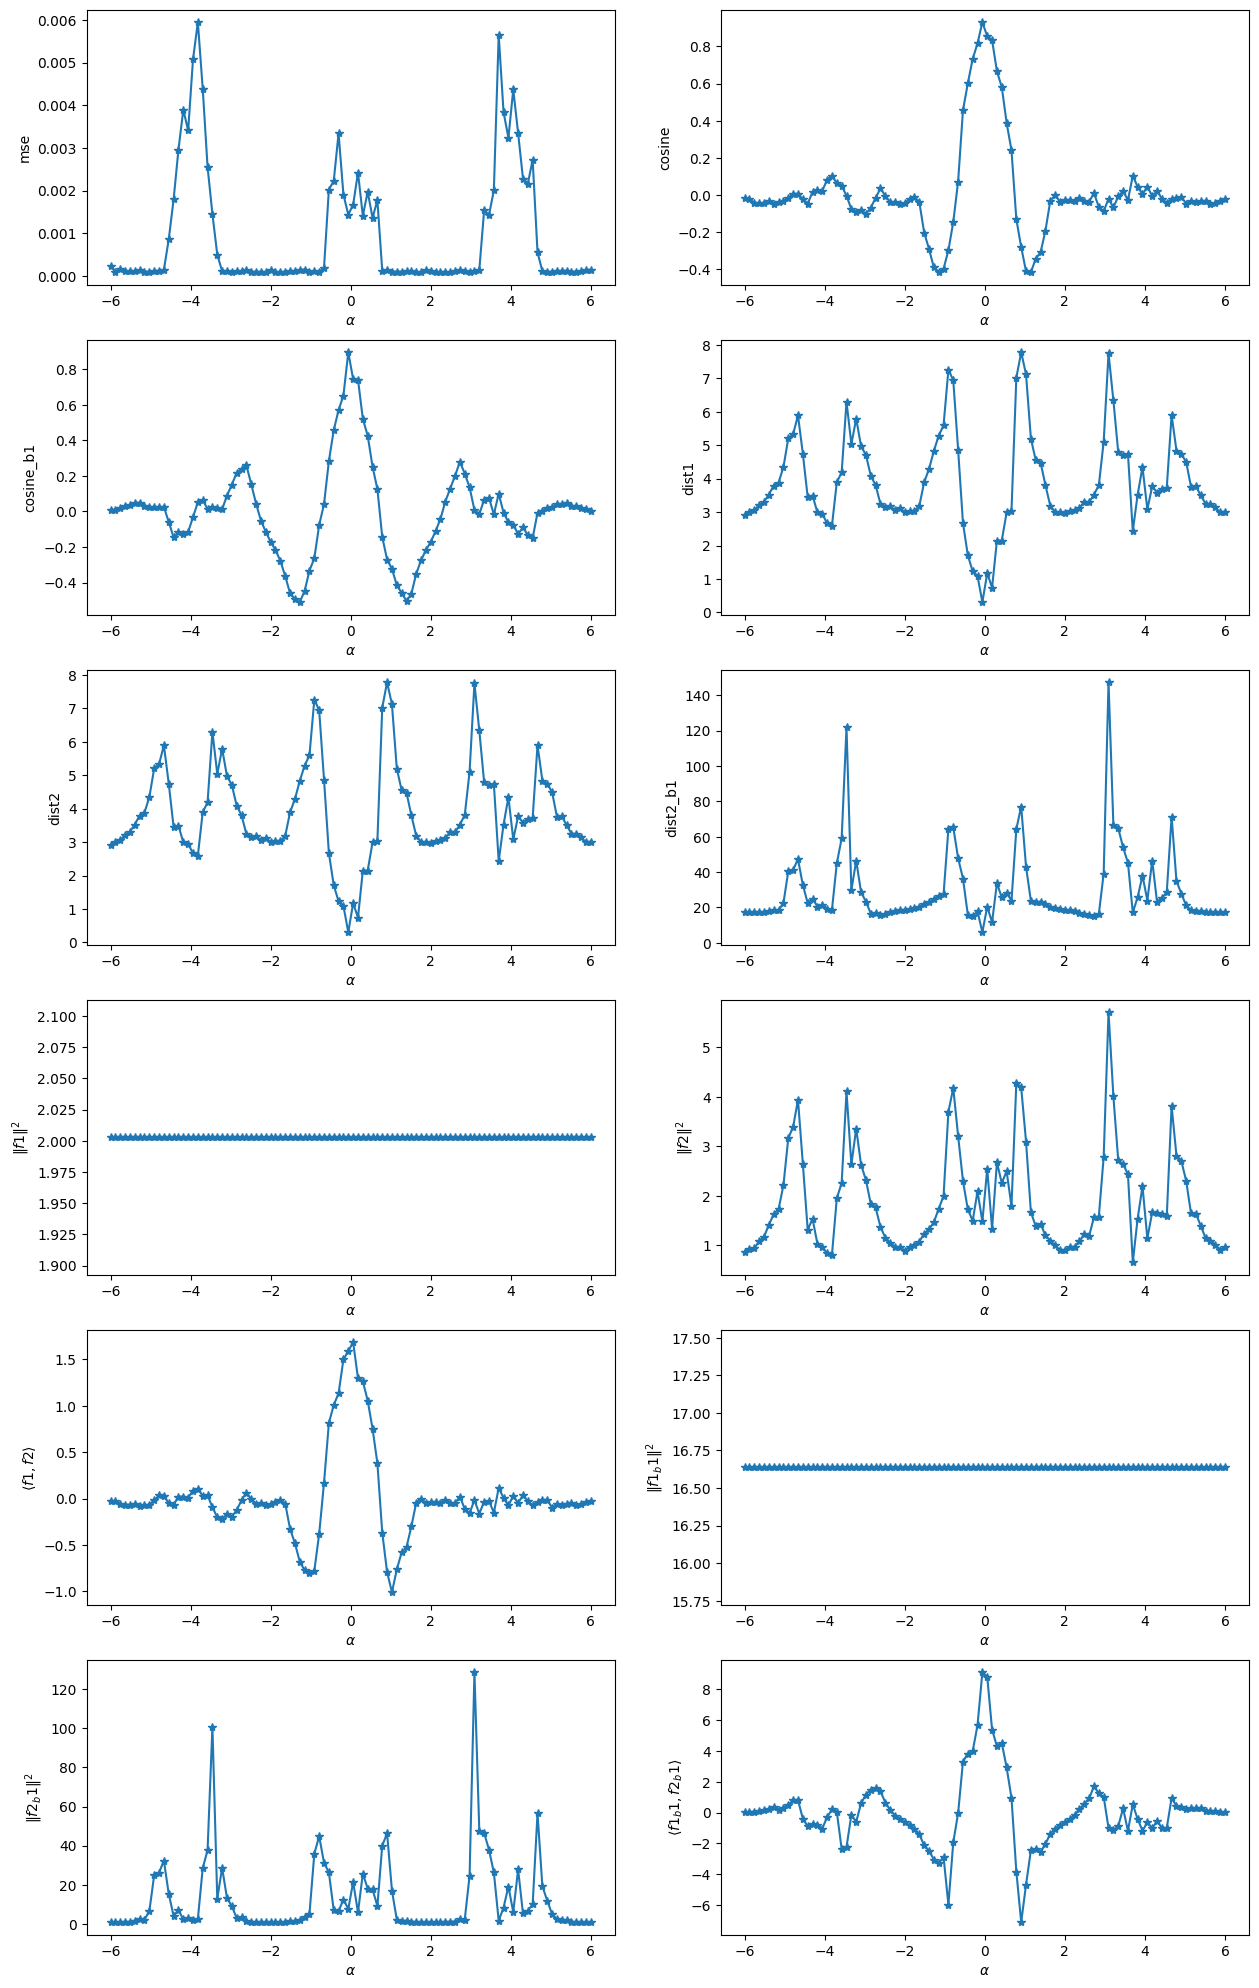

In [73]:
fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(15, 25))

for k, ax_ in zip(results.keys(), ax.flat):
    ax_.plot(alphas[:len(results[k])], results[k], "-*")
    ax_.set_ylabel(k)
    ax_.set_xlabel("$\\alpha$")